# PINN Analysis — Physics Residual & Boundary Condition Losses

**Goal:** understand where and how much the trained ThermalNet violates
the three constraints it was trained on:

| Loss | What it checks | Where |
|------|---------------|-------|
| Physics (∇²T̂ = 0) | Laplacian of predicted temperature | all nodes |
| Dirichlet (T̂ = T_fix) | Temperature at fixed-temperature face | x ≈ 0 |
| Neumann (∂T̂/∂x = q/kA) | Temperature gradient at heat-flux face | x ≈ L |

**Model:** `saves/thermal_pinn.pt`  
**Dataset:** 25 test cases (5 materials × 5 Q levels, covering extrap-below / interp / extrap-above)

In [5]:
import sys, json
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import meshio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from IPython.display import display as ipy_display
from scipy.stats import spearmanr

ROOT        = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))
from arch import ThermalNet

ELMER_CASES = ROOT / 'elmer_cases' / 'thermal_ccx_beam'
SAVES       = ROOT / 'saves'
LOG_COLS    = [3]

# Beam geometry (matches losses.py)
X_MIN_MM      = 0.0
X_MAX_MM      = 1000.0
BEAM_AREA_MM2 = 10_000.0   # 100 mm × 100 mm
BC_TOL_MM     = 20.0

MATERIAL_K = {
    'Steel_A36':        50.0,
    'Steel_S355':       48.0,
    'Aluminium_6061':  167.0,
    'Titanium_Ti6Al4V':  6.7,
    'Concrete_C30':      1.8,
}
MAT_ORDER = list(MATERIAL_K.keys())
MAT_COLORS = {m: plt.cm.tab10.colors[i] for i, m in enumerate(MAT_ORDER)}
REGIME_MARKERS = {'extrap-below': 'v', 'interp': 'o', 'extrap-above': '^'}

print('ROOT:', ROOT)
print('PyTorch:', torch.__version__)

ROOT: /home/riccardo/Documents/AI_for_NumSim/01_beam_studies/Beam_FEM_Thermal_CCX
PyTorch: 2.7.1


## 1 — Load model and normalisation parameters

In [ ]:
ckpt  = torch.load(SAVES / 'thermal_pinn_h512-lp10.0-ld1.0-ln1.0-e50.pt', map_location='cpu', weights_only=True)
model = ThermalNet(hidden=ckpt['hidden'])
state = ckpt['model_state']
if any(k.startswith('module.') for k in state):
    state = {k[len('module.'):]: v for k, v in state.items()}
model.load_state_dict(state)
model.eval()

norm   = dict(np.load(SAVES / 'norm_params.npz'))
X_mean = norm['X_mean']          # (6,)
X_std  = norm['X_std']           # (6,)
Y_mean = float(norm['Y_mean'])
Y_std  = float(norm['Y_std'])

# Normalised face positions and tolerance (match losses.py)
x0_norm  = (X_MIN_MM - X_mean[0]) / X_std[0]
xL_norm  = (X_MAX_MM - X_mean[0]) / X_std[0]
tol_norm = BC_TOL_MM / X_std[0]

n_params = sum(p.numel() for p in model.parameters())
print(f'ThermalNet  hidden={ckpt["hidden"]}  params={n_params:,}')
print(f'Y_mean = {Y_mean:.2f} °C    Y_std = {Y_std:.2f} °C')
print(f'Dirichlet face  x_norm ≈ {x0_norm:.4f}  (±{tol_norm:.4f})')
print(f'Neumann   face  x_norm ≈ {xL_norm:.4f}  (±{tol_norm:.4f})')

ThermalNet  hidden=512  params=792,065
Y_mean = 243.45 °C    Y_std = 699.79 °C
Dirichlet face  x_norm ≈ -1.6876  (±0.0676)
Neumann   face  x_norm ≈ 1.6935  (±0.0676)


/tmp/ipykernel_304492/2066574719.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y_mean = float(norm['Y_mean'])
/tmp/ipykernel_304492/2066574719.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y_std  = float(norm['Y_std'])


## 2 — Helper functions

### 2a — Data loading

In [7]:
def normalise_X(X: np.ndarray) -> np.ndarray:
    X_p = X.copy()
    for c in LOG_COLS:
        X_p[:, c] = np.log(X_p[:, c])
    return ((X_p - X_mean) / X_std).astype(np.float32)


def load_case(case_id: str) -> dict:
    """
    Load one case and return a dict with:
      coords   (N, 3)  — x, y, z in mm
      true_C   (N,)    — FEM temperature [°C]
      X_n      (N, 6)  — normalised feature matrix
      pred_C   (N,)    — model prediction [°C]
      params   dict    — case metadata
      k_val    float   — conductivity [mW/mm/°C]
    """
    case_dir   = ELMER_CASES / case_id
    params     = json.loads((case_dir / 'case_params.json').read_text())
    mesh       = meshio.read(str(case_dir / 'case.vtk'))
    coords     = mesh.points.astype(np.float32)

    temp_key   = next(k for k in mesh.point_data if k.lower() == 'temperature')
    true_C     = mesh.point_data[temp_key].squeeze().astype(np.float32)

    k_val      = MATERIAL_K.get(params['material'], params.get('k_mW_mm_C', 1.0))
    N          = len(coords)
    case_feats = np.tile(
        np.array([params['q_total_mW'], k_val, params['T_fix_C']], dtype=np.float32),
        (N, 1)
    )
    X          = np.hstack([coords, case_feats])
    X_n        = normalise_X(X)

    with torch.no_grad():
        Y_n    = model(torch.from_numpy(X_n)).numpy()
    pred_C     = (Y_n * Y_std + Y_mean).squeeze().astype(np.float32)

    return dict(coords=coords, true_C=true_C, X_n=X_n,
                pred_C=pred_C, params=params, k_val=k_val)


print('Data helpers defined.')

Data helpers defined.


### 2b — Physics residual functions

In [8]:
def compute_physics_fields(X_n: np.ndarray, batch_size: int = 512) -> tuple:
    """
    Compute per-node Laplacian residual and x-gradient in one autograd pass.

    Returns
    -------
    lap_norm  : (N,) float32  — signed ∇²T̂ in normalised space
    dTdx_phys : (N,) float32  — ∂T/∂x in physical units [°C/mm]
    """
    all_lap, all_dTdx = [], []
    X_t = torch.from_numpy(X_n)

    for i in range(0, len(X_t), batch_size):
        xb = X_t[i:i + batch_size].clone().requires_grad_(True)
        T  = model(xb)
        g  = torch.autograd.grad(T.sum(), xb, create_graph=True)[0][:, :3]  # (B, 3)

        all_dTdx.append((g[:, 0].detach().numpy() * Y_std / X_std[0]))

        lap = torch.zeros(len(xb))
        for j in range(3):
            g2  = torch.autograd.grad(g[:, j].sum(), xb,
                                      retain_graph=(j < 2), create_graph=False)[0]
            lap = lap + g2[:, j].detach()
        all_lap.append(lap.numpy())

    return (np.concatenate(all_lap).astype(np.float32),
            np.concatenate(all_dTdx).astype(np.float32))


print('Physics field helper defined.')

Physics field helper defined.


### 2c — Boundary condition residual functions

In [9]:
def compute_dirichlet_residuals(X_n: np.ndarray, pred_C: np.ndarray,
                               T_fix: float) -> tuple:
    """
    Returns (mask, residual) for nodes near the Dirichlet face (x ≈ 0).
    residual = T̂ - T_fix  [°C], signed.
    """
    mask     = np.abs(X_n[:, 0] - x0_norm) < tol_norm
    residual = pred_C[mask] - T_fix
    return mask, residual


def compute_neumann_residuals(X_n: np.ndarray,
                              q_mW: float, k_val: float,
                              batch_size: int = 512) -> tuple:
    """
    Returns (mask, pred_grad, target_grad, residual) for nodes near x = L.
    pred_grad and residual are in [°C/mm], signed.
    """
    mask        = np.abs(X_n[:, 0] - xL_norm) < tol_norm
    X_bc        = X_n[mask]
    target_grad = q_mW / (k_val * BEAM_AREA_MM2)   # [°C/mm]

    all_grad = []
    for start in range(0, len(X_bc), batch_size):
        xb = torch.from_numpy(X_bc[start:start + batch_size])
        with torch.enable_grad():
            x  = xb.clone().detach().requires_grad_(True)
            T  = model(x)
            dT_dx_norm = torch.autograd.grad(
                T.sum(), x, create_graph=False)[0][:, 0].detach().numpy()
        all_grad.append(dT_dx_norm * Y_std / X_std[0])

    pred_grad = np.concatenate(all_grad).astype(np.float32)
    residual  = pred_grad - target_grad
    return mask, pred_grad, target_grad, residual


print('BC residual helpers defined.')

BC residual helpers defined.


---
## 3 — Single-case deep dive

Reference case: **Steel_A36, Q = 52.5 W** (interpolation regime).
We compute all residuals and examine each loss spatially.

In [10]:
CASE_ID = 'case_0102'   # Steel_A36, Q=52.5 W, interpolation

print(f'Loading {CASE_ID} …')
case   = load_case(CASE_ID)
coords = case['coords']
true_C = case['true_C']
pred_C = case['pred_C']
X_n    = case['X_n']
params = case['params']
k_val  = case['k_val']
q_mW   = params['q_total_mW']
T_fix  = params['T_fix_C']
err    = np.abs(pred_C - true_C)

print(f'  Material : {params["material"]}   k = {k_val} mW/mm/°C')
print(f'  Q        : {q_mW:.1f} mW  ({q_mW/1000:.3f} W)')
print(f'  T_fix    : {T_fix} °C   |   Nodes: {len(coords):,}')
print(f'  MAE      : {err.mean():.3f} °C   max |ΔT| = {err.max():.3f} °C')

print('\nComputing physics fields …')
lap_vals, dTdx_all = compute_physics_fields(X_n)
lap_abs = np.abs(lap_vals)

print('Computing BC residuals …')
dir_mask, dir_res  = compute_dirichlet_residuals(X_n, pred_C, T_fix)
neu_mask, neu_pred_grad, neu_target_grad, neu_res = compute_neumann_residuals(X_n, q_mW, k_val)
neu_abs_all = np.abs(dTdx_all - neu_target_grad)

print(f'\n--- Laplacian ---')
print(f'  mean |∇²T̂| = {lap_abs.mean():.5f}   max = {lap_abs.max():.5f}')
print(f'\n--- Dirichlet face (x≈0)  [{dir_mask.sum()} nodes] ---')
print(f'  T̂ - T_fix : mean={dir_res.mean():.4f} °C   std={dir_res.std():.4f} °C   max|·|={np.abs(dir_res).max():.4f} °C')
print(f'\n--- Neumann face (x≈L)  [{neu_mask.sum()} nodes] ---')
print(f'  Target   ∂T/∂x = {neu_target_grad:.6f} °C/mm')
print(f'  Predicted ∂T/∂x = {neu_pred_grad.mean():.6f} ± {neu_pred_grad.std():.6f} °C/mm')
print(f'  Relative error = {np.abs(neu_res).mean()/neu_target_grad*100:.2f} %')

Loading case_0102 …
  Material : Steel_A36   k = 50.0 mW/mm/°C
  Q        : 52500.0 mW  (52.500 W)
  T_fix    : 20.0 °C   |   Nodes: 9,314
  MAE      : 17.642 °C   max |ΔT| = 50.997 °C

Computing physics fields …
Computing BC residuals …

--- Laplacian ---
  mean |∇²T̂| = 0.00722   max = 0.02204

--- Dirichlet face (x≈0)  [286 nodes] ---
  T̂ - T_fix : mean=13.1217 °C   std=0.9646 °C   max|·|=15.2464 °C

--- Neumann face (x≈L)  [285 nodes] ---
  Target   ∂T/∂x = 0.105000 °C/mm
  Predicted ∂T/∂x = 0.091363 ± 0.002908 °C/mm
  Relative error = 12.99 %


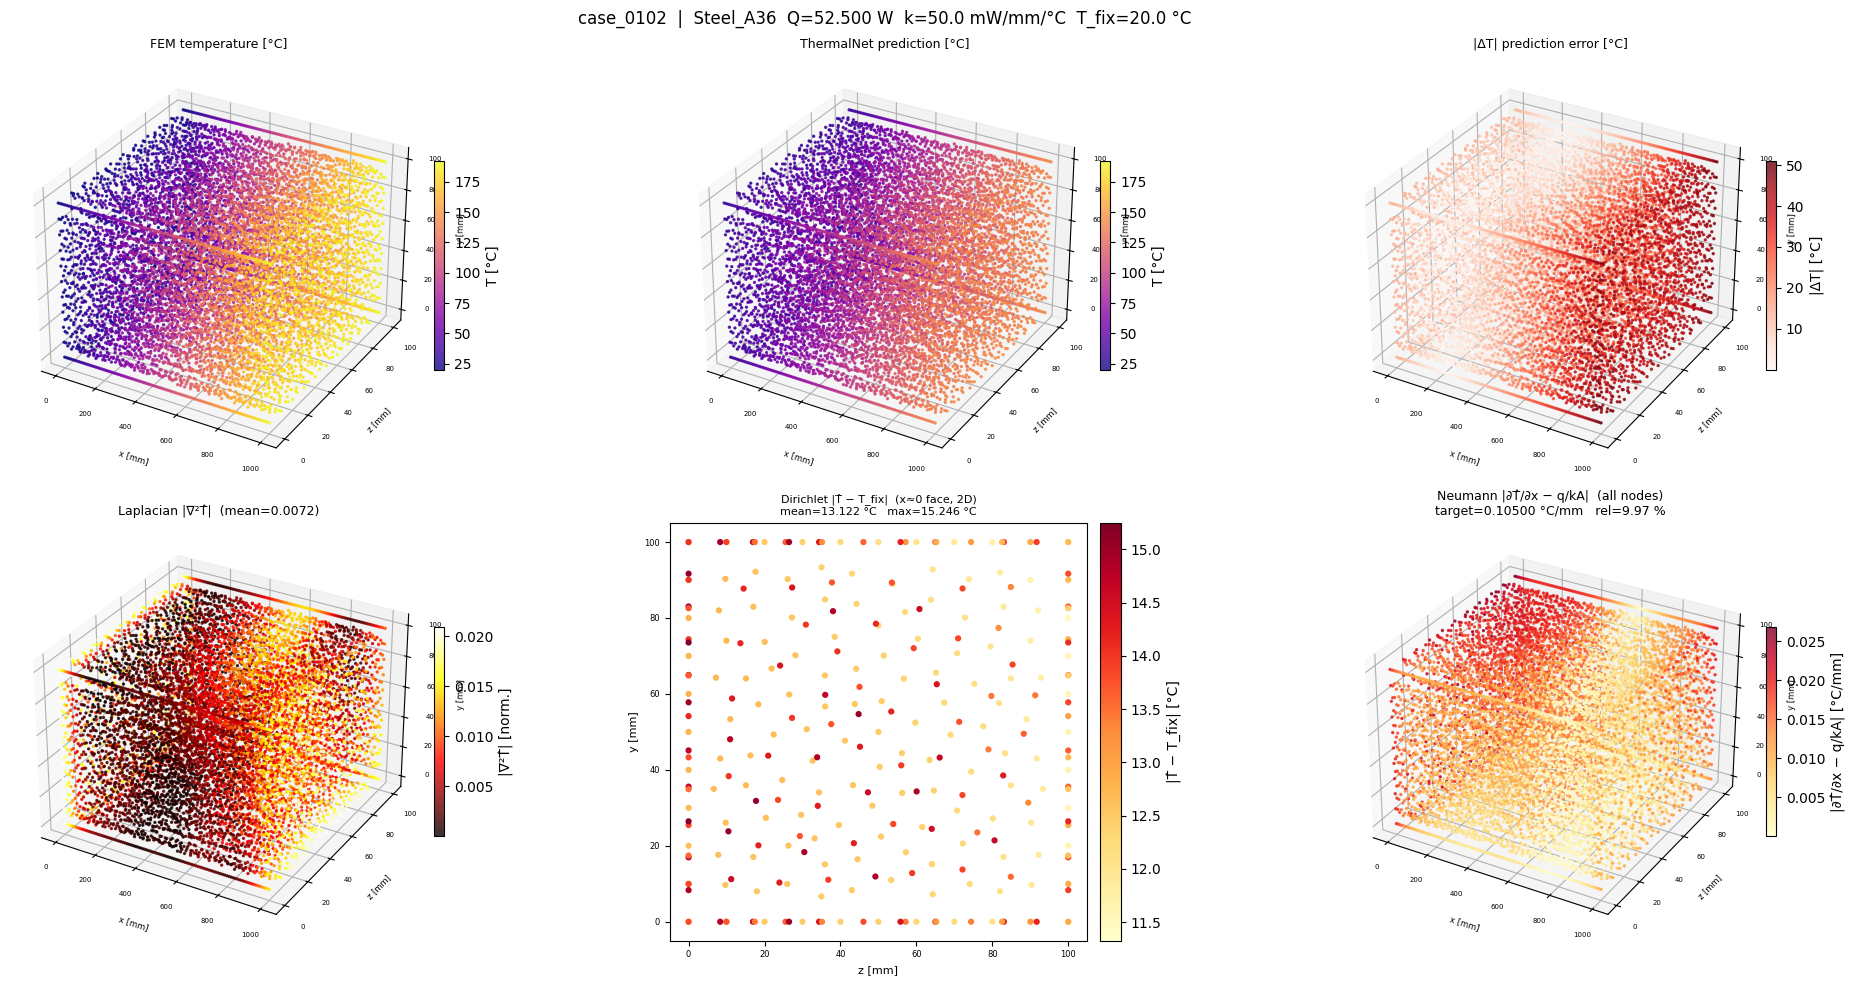

In [11]:
# 2×3 overview: row 1 = data fields | row 2 = residuals
x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]
y_dir = coords[dir_mask, 1]
z_dir = coords[dir_mask, 2]
vmin_T, vmax_T = true_C.min(), true_C.max()

fig = plt.figure(figsize=(20, 10))
fig.suptitle(
    f'{CASE_ID}  |  {params["material"]}  Q={q_mW/1000:.3f} W  '
    f'k={k_val} mW/mm/°C  T_fix={T_fix} °C',
    fontsize=12
)

def add3d(pos):
    return fig.add_subplot(2, 3, pos, projection='3d')

def fmt3d(ax, title, fontsize=9):
    ax.set_title(title, fontsize=fontsize)
    ax.set_xlabel('x [mm]', fontsize=6); ax.set_ylabel('z [mm]', fontsize=6)
    ax.set_zlabel('y [mm]', fontsize=6); ax.tick_params(labelsize=5)

# Row 1: data fields
ax1 = add3d(1)
sc1 = ax1.scatter(x, z, y, c=true_C, cmap='plasma', vmin=vmin_T, vmax=vmax_T, s=2, alpha=0.8)
fig.colorbar(sc1, ax=ax1, shrink=0.5, label='T [°C]', pad=0.01)
fmt3d(ax1, 'FEM temperature [°C]')

ax2 = add3d(2)
sc2 = ax2.scatter(x, z, y, c=pred_C, cmap='plasma', vmin=vmin_T, vmax=vmax_T, s=2, alpha=0.8)
fig.colorbar(sc2, ax=ax2, shrink=0.5, label='T [°C]', pad=0.01)
fmt3d(ax2, 'ThermalNet prediction [°C]')

ax3 = add3d(3)
sc3 = ax3.scatter(x, z, y, c=err, cmap='Reds', s=2, alpha=0.8)
fig.colorbar(sc3, ax=ax3, shrink=0.5, label='|ΔT| [°C]', pad=0.01)
fmt3d(ax3, '|ΔT| prediction error [°C]')

# Row 2: residuals
ax4 = add3d(4)
sc4 = ax4.scatter(x, z, y, c=lap_abs, cmap='hot', vmax=np.percentile(lap_abs, 99), s=2, alpha=0.8)
fig.colorbar(sc4, ax=ax4, shrink=0.5, label='|∇²T̂| [norm.]', pad=0.01)
fmt3d(ax4, f'Laplacian |∇²T̂|  (mean={lap_abs.mean():.4f})')

ax5 = fig.add_subplot(2, 3, 5)   # 2D — Dirichlet face
sc5 = ax5.scatter(z_dir, y_dir, c=np.abs(dir_res), cmap='YlOrRd', s=12)
fig.colorbar(sc5, ax=ax5, label='|T̂ − T_fix| [°C]', pad=0.02)
ax5.set_xlabel('z [mm]', fontsize=8); ax5.set_ylabel('y [mm]', fontsize=8)
ax5.set_title(f'Dirichlet |T̂ − T_fix|  (x≈0 face, 2D)\n'
              f'mean={np.abs(dir_res).mean():.3f} °C   max={np.abs(dir_res).max():.3f} °C', fontsize=8)
ax5.set_aspect('equal'); ax5.tick_params(labelsize=6)

ax6 = add3d(6)
sc6 = ax6.scatter(x, z, y, c=neu_abs_all, cmap='YlOrRd', s=2, alpha=0.8)
fig.colorbar(sc6, ax=ax6, shrink=0.5, label='|∂T̂/∂x − q/kA| [°C/mm]', pad=0.01)
fmt3d(ax6, f'Neumann |∂T̂/∂x − q/kA|  (all nodes)\n'
           f'target={neu_target_grad:.5f} °C/mm   rel={neu_abs_all.mean()/neu_target_grad*100:.2f} %')

plt.tight_layout()
plt.savefig(SAVES / f'pinn_overview_{CASE_ID}.png', dpi=120, bbox_inches='tight')
ipy_display(fig)
plt.close(fig)

### Spatial profile along the beam axis

For steady-state 1D conduction the exact solution is **linear in x**.
The Laplacian should be zero everywhere; spikes near the boundary faces reveal where
the network struggles.

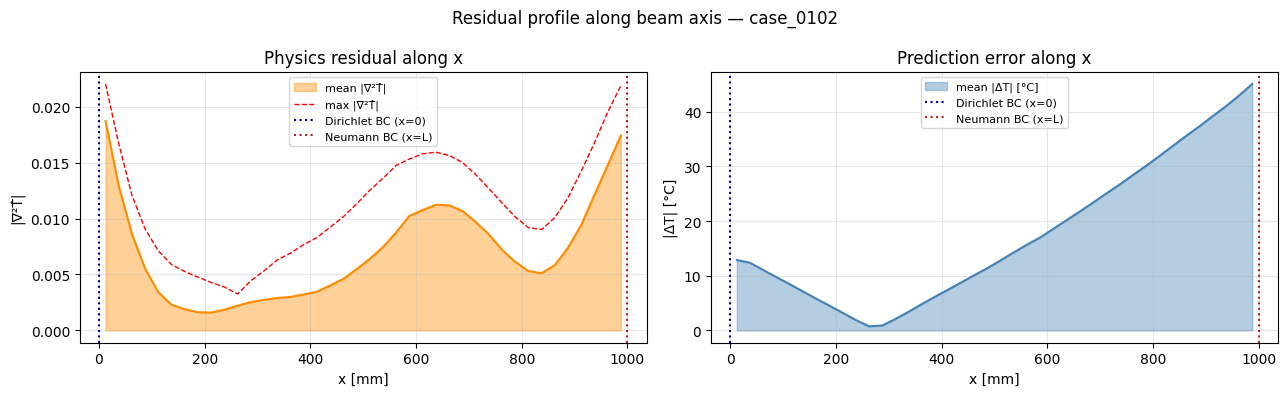

In [12]:
N_BINS  = 40
x_edges = np.linspace(x.min(), x.max(), N_BINS + 1)
xc      = 0.5 * (x_edges[:-1] + x_edges[1:])
bidx    = np.clip(np.digitize(x, x_edges) - 1, 0, N_BINS - 1)

mean_lap = np.array([lap_abs[bidx == b].mean() if (bidx == b).any() else 0 for b in range(N_BINS)])
max_lap  = np.array([lap_abs[bidx == b].max()  if (bidx == b).any() else 0 for b in range(N_BINS)])
mean_err = np.array([err[bidx == b].mean()     if (bidx == b).any() else 0 for b in range(N_BINS)])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Residual profile along beam axis — {CASE_ID}', fontsize=12)

ax = axes[0]
ax.fill_between(xc, mean_lap, alpha=0.4, color='darkorange', label='mean |∇²T̂|')
ax.plot(xc, mean_lap, color='darkorange', linewidth=1.5)
ax.plot(xc, max_lap,  color='red', linestyle='--', linewidth=1, label='max |∇²T̂|')
ax.axvline(0,    color='navy',     linestyle=':', linewidth=1.5, label='Dirichlet BC (x=0)')
ax.axvline(1000, color='firebrick',linestyle=':', linewidth=1.5, label='Neumann BC (x=L)')
ax.set_xlabel('x [mm]'); ax.set_ylabel('|∇²T̂|')
ax.set_title('Physics residual along x'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.fill_between(xc, mean_err, alpha=0.4, color='steelblue', label='mean |ΔT| [°C]')
ax2.plot(xc, mean_err, color='steelblue', linewidth=1.5)
ax2.axvline(0,    color='navy',     linestyle=':', linewidth=1.5, label='Dirichlet BC (x=0)')
ax2.axvline(1000, color='firebrick',linestyle=':', linewidth=1.5, label='Neumann BC (x=L)')
ax2.set_xlabel('x [mm]'); ax2.set_ylabel('|ΔT| [°C]')
ax2.set_title('Prediction error along x'); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVES / f'pinn_profile_{CASE_ID}.png', dpi=130)
ipy_display(fig); plt.close(fig)

### Correlation: |∇²T̂| vs |ΔT|

If the physics loss is meaningful, nodes with high Laplacian residual should predict high error.

Spearman ρ(|∇²T̂|, |ΔT|) = 0.583   (p = 0.00e+00)


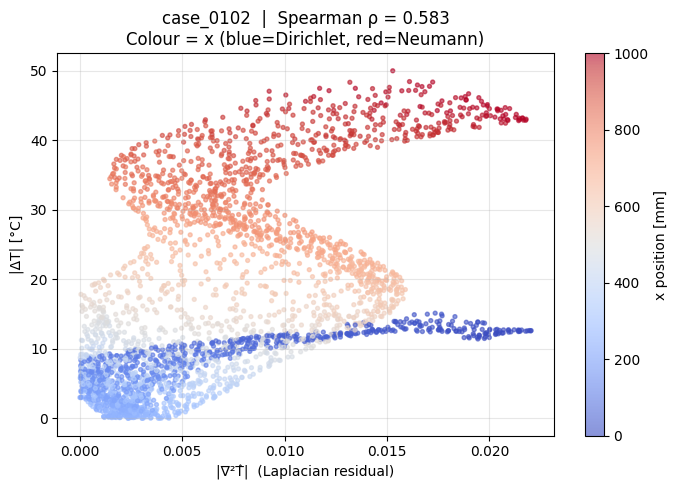

In [13]:
rho, pval = spearmanr(lap_abs, err)
print(f'Spearman ρ(|∇²T̂|, |ΔT|) = {rho:.3f}   (p = {pval:.2e})')

rng = np.random.default_rng(0)
idx = rng.choice(len(lap_abs), size=min(3000, len(lap_abs)), replace=False)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(lap_abs[idx], err[idx], c=coords[idx, 0], cmap='coolwarm', s=8, alpha=0.6)
plt.colorbar(sc, ax=ax, label='x position [mm]')
ax.set_xlabel('|∇²T̂|  (Laplacian residual)'); ax.set_ylabel('|ΔT| [°C]')
ax.set_title(f'{CASE_ID}  |  Spearman ρ = {rho:.3f}\nColour = x (blue=Dirichlet, red=Neumann)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SAVES / f'pinn_corr_{CASE_ID}.png', dpi=130)
ipy_display(fig); plt.close(fig)

### Dirichlet face detail (x ≈ 0)

At x=0, the model must predict exactly `T_fix` for every cross-section node.

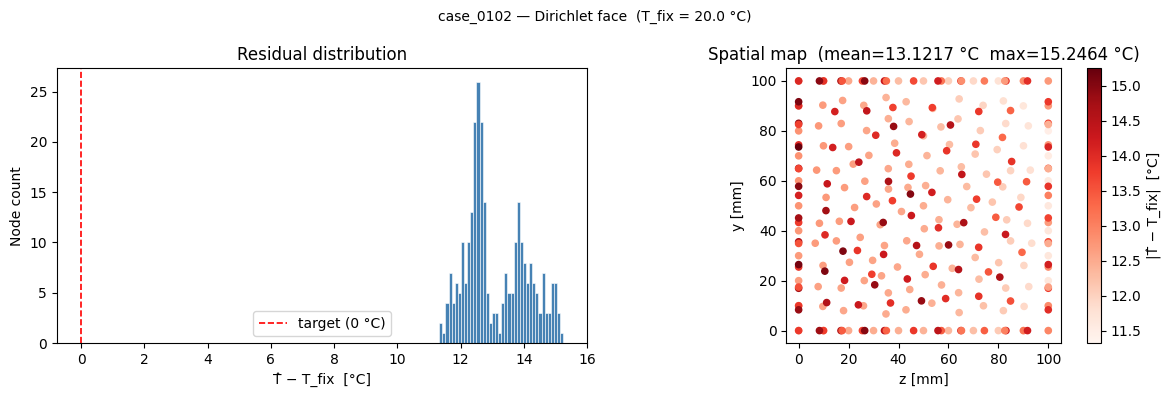

In [14]:
y_face = coords[dir_mask, 1]
z_face = coords[dir_mask, 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'{CASE_ID} — Dirichlet face  (T_fix = {T_fix} °C)', fontsize=10)

ax = axes[0]
ax.hist(dir_res, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='target (0 °C)')
ax.set_xlabel('T̂ − T_fix  [°C]'); ax.set_ylabel('Node count')
ax.set_title('Residual distribution'); ax.legend()

ax = axes[1]
sc = ax.scatter(z_face, y_face, c=np.abs(dir_res), cmap='Reds', s=20)
fig.colorbar(sc, ax=ax, label='|T̂ − T_fix|  [°C]')
ax.set_xlabel('z [mm]'); ax.set_ylabel('y [mm]')
ax.set_title(f'Spatial map  (mean={np.abs(dir_res).mean():.4f} °C  max={np.abs(dir_res).max():.4f} °C)')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(SAVES / f'pinn_dirichlet_{CASE_ID}.png', dpi=120, bbox_inches='tight')
ipy_display(fig); plt.close(fig)

### Neumann face detail (x ≈ L)

At x=L, the model's gradient `∂T̂/∂x` must match `q/(k·A)`.

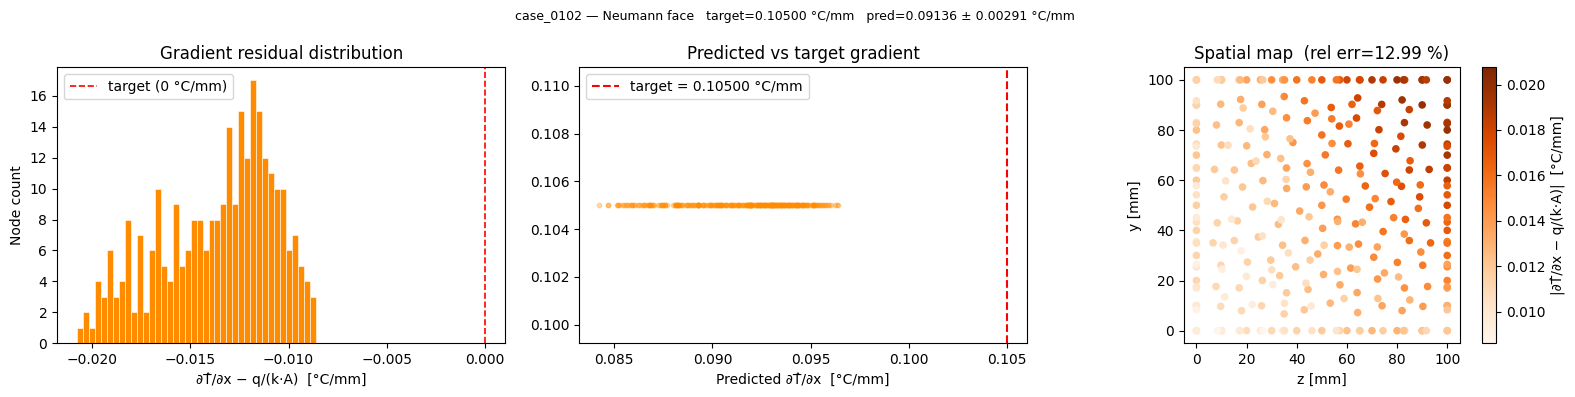

In [15]:
y_face_neu = coords[neu_mask, 1]
z_face_neu = coords[neu_mask, 2]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(
    f'{CASE_ID} — Neumann face   '
    f'target={neu_target_grad:.5f} °C/mm   '
    f'pred={neu_pred_grad.mean():.5f} ± {neu_pred_grad.std():.5f} °C/mm', fontsize=9
)

ax = axes[0]
ax.hist(neu_res, bins=40, color='darkorange', edgecolor='white', linewidth=0.4)
ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='target (0 °C/mm)')
ax.set_xlabel('∂T̂/∂x − q/(k·A)  [°C/mm]'); ax.set_ylabel('Node count')
ax.set_title('Gradient residual distribution'); ax.legend()

ax = axes[1]
ax.scatter(neu_pred_grad, [neu_target_grad] * len(neu_pred_grad), alpha=0.3, s=10, color='darkorange')
ax.axvline(neu_target_grad, color='red', linestyle='--', linewidth=1.5,
           label=f'target = {neu_target_grad:.5f} °C/mm')
ax.set_xlabel('Predicted ∂T̂/∂x  [°C/mm]'); ax.set_title('Predicted vs target gradient'); ax.legend()

ax = axes[2]
sc = ax.scatter(z_face_neu, y_face_neu, c=np.abs(neu_res), cmap='Oranges', s=20)
fig.colorbar(sc, ax=ax, label='|∂T̂/∂x − q/(k·A)|  [°C/mm]')
ax.set_xlabel('z [mm]'); ax.set_ylabel('y [mm]')
ax.set_title(f'Spatial map  (rel err={np.abs(neu_res).mean()/neu_target_grad*100:.2f} %)')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(SAVES / f'pinn_neumann_{CASE_ID}.png', dpi=120, bbox_inches='tight')
ipy_display(fig); plt.close(fig)

---
## 4 — Multi-case comparison: Steel_A36, all Q levels

How do the residuals evolve from below the training range → training range → above?

| case_id   | Q [W]  | regime        |
|-----------|--------|---------------|
| case_0100 |   0.1  | extrap-below  |
| case_0101 |   0.3  | extrap-below  |
| case_0102 |  52.5  | interp        |
| case_0103 | 200.0  | extrap-above  |
| case_0104 | 500.0  | extrap-above  |

In [16]:
STEEL_CASES = [
    ('case_0100',  'extrap-below', 'C0'),
    ('case_0101',  'extrap-below', 'C1'),
    ('case_0102',  'interp',       'C2'),
    ('case_0103',  'extrap-above', 'C3'),
    ('case_0104',  'extrap-above', 'C4'),
]

mc_results = []
for case_id, regime, color in STEEL_CASES:
    c      = load_case(case_id)
    q_mW_c = c['params']['q_total_mW']
    T_fix_c = c['params']['T_fix_C']
    k_c    = c['k_val']
    err_c  = np.abs(c['pred_C'] - c['true_C'])

    lap_c, dTdx_c = compute_physics_fields(c['X_n'])
    dm, dr        = compute_dirichlet_residuals(c['X_n'], c['pred_C'], T_fix_c)
    nm, ng, tg, nr = compute_neumann_residuals(c['X_n'], q_mW_c, k_c)

    mc_results.append(dict(
        case_id=case_id, regime=regime, color=color,
        q_W=q_mW_c/1000, coords=c['coords'],
        abs_lap=np.abs(lap_c), err=err_c,
        dir_mae=np.abs(dr).mean(),
        neu_target=tg, neu_pred_mean=ng.mean(),
        neu_mae=np.abs(nr).mean(),
        neu_rel_pct=np.abs(nr).mean()/tg*100 if tg > 0 else np.nan,
    ))
    print(f'  {case_id}  Q={q_mW_c/1000:>7.2f} W  [{regime:14s}]  '
          f'MAE={err_c.mean():7.2f} °C  |∇²T̂|={np.abs(lap_c).mean():.3e}  '
          f'|Dir|={np.abs(dr).mean():.3f} °C  |Neu|={np.abs(nr).mean()/tg*100:.1f} %')

  case_0100  Q=   0.10 W  [extrap-below  ]  MAE=  11.60 °C  |∇²T̂|=1.188e-03  |Dir|=8.049 °C  |Neu|=1882.9 %
  case_0101  Q=   0.30 W  [extrap-below  ]  MAE=  12.12 °C  |∇²T̂|=1.625e-03  |Dir|=8.605 °C  |Neu|=691.1 %
  case_0102  Q=  52.50 W  [interp        ]  MAE=  17.64 °C  |∇²T̂|=7.215e-03  |Dir|=13.122 °C  |Neu|=13.0 %
  case_0103  Q= 200.00 W  [extrap-above  ]  MAE= 148.98 °C  |∇²T̂|=5.996e-02  |Dir|=43.716 °C  |Neu|=90.6 %
  case_0104  Q= 500.00 W  [extrap-above  ]  MAE= 570.84 °C  |∇²T̂|=7.188e-02  |Dir|=97.134 °C  |Neu|=97.5 %


### Physics residual: profile along x and distribution

/tmp/ipykernel_304492/3013365059.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


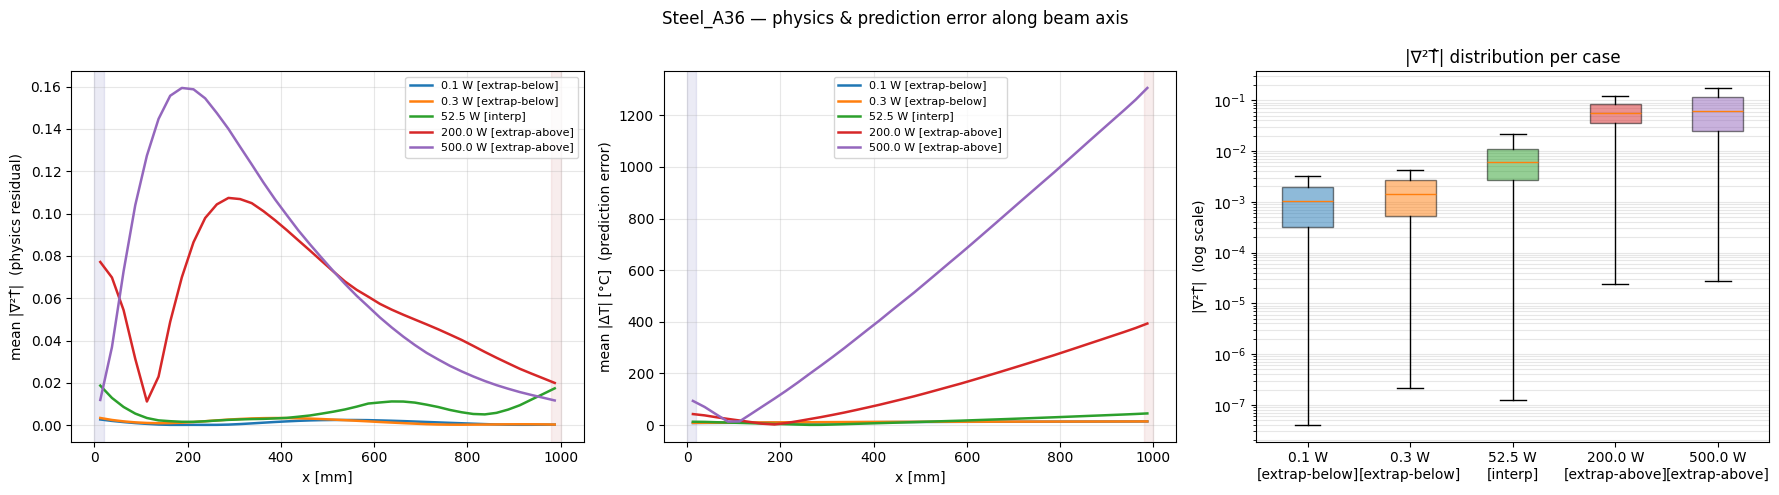

In [17]:
N_BINS = 40

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Steel_A36 — physics & prediction error along beam axis', fontsize=12)

for ax, key, ylabel in zip(
    axes[:2],
    ['abs_lap', 'err'],
    ['mean |∇²T̂|  (physics residual)', 'mean |ΔT| [°C]  (prediction error)'],
):
    for r in mc_results:
        xs = r['coords'][:, 0]
        xe = np.linspace(xs.min(), xs.max(), N_BINS + 1)
        xc2 = 0.5 * (xe[:-1] + xe[1:])
        bi  = np.clip(np.digitize(xs, xe) - 1, 0, N_BINS - 1)
        v   = r[key]
        mv  = np.array([v[bi == b].mean() if (bi == b).any() else 0 for b in range(N_BINS)])
        ax.plot(xc2, mv, color=r['color'], linewidth=1.8,
                label=f"{r['q_W']} W [{r['regime']}]")
    ax.axvspan(0,   BC_TOL_MM,             alpha=0.08, color='navy')
    ax.axvspan(X_MAX_MM - BC_TOL_MM, X_MAX_MM, alpha=0.08, color='firebrick')
    ax.set_xlabel('x [mm]'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Boxplot of |∇²T̂| distribution
ax = axes[2]
bp = ax.boxplot(
    [r['abs_lap'] for r in mc_results],
    labels=[f"{r['q_W']} W\n[{r['regime']}]" for r in mc_results],
    patch_artist=True,
    flierprops=dict(marker='.', markersize=2, alpha=0.3),
)
for patch, r in zip(bp['boxes'], mc_results):
    patch.set_facecolor(r['color']); patch.set_alpha(0.5)
ax.set_yscale('log'); ax.set_ylabel('|∇²T̂|  (log scale)')
ax.set_title('|∇²T̂| distribution per case'); ax.grid(True, which='both', alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(SAVES / 'pinn_multicase_physics_steel.png', dpi=130)
ipy_display(fig); plt.close(fig)

### BC residuals vs Q level

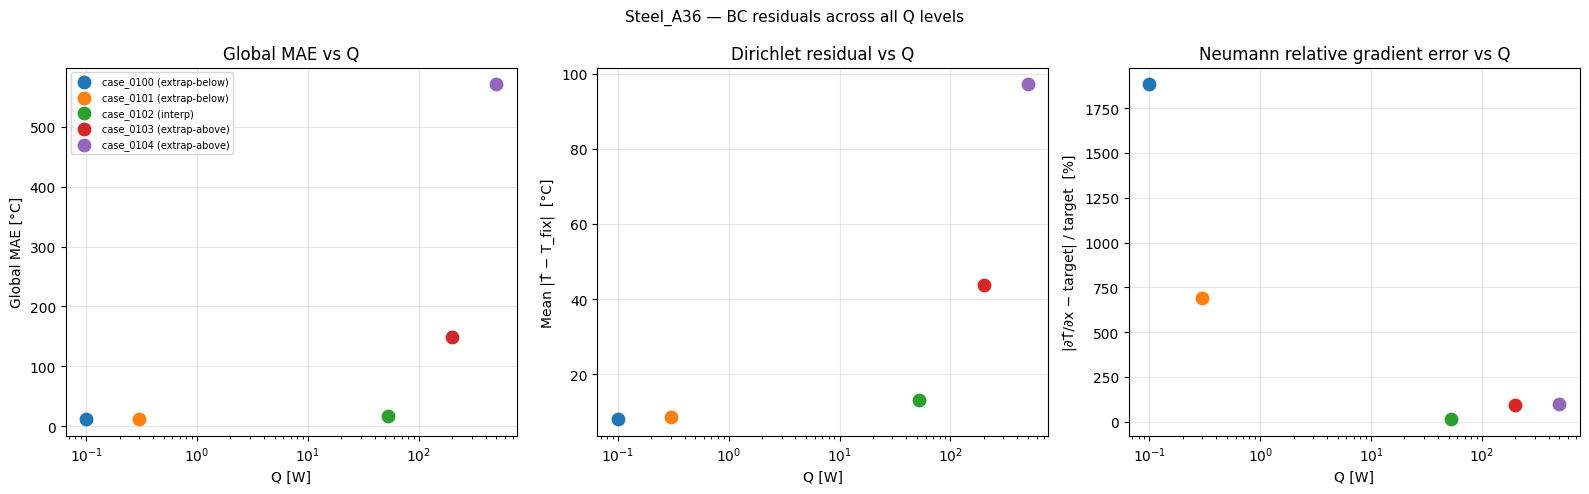

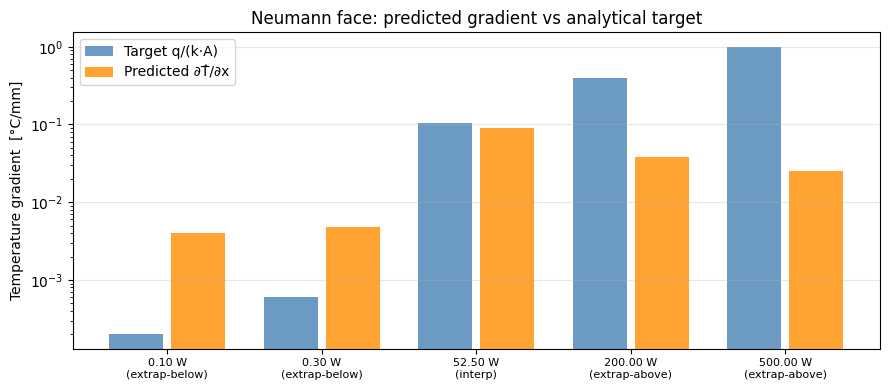

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Steel_A36 — BC residuals across all Q levels', fontsize=11)

# Panel 1: Global MAE vs Q
ax = axes[0]
for r in mc_results:
    ax.scatter(r['q_W'], r['err'].mean(), color=r['color'], s=80,
               label=f"{r['case_id']} ({r['regime']})", zorder=3)
ax.set_xscale('log'); ax.set_xlabel('Q [W]'); ax.set_ylabel('Global MAE [°C]')
ax.set_title('Global MAE vs Q'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Panel 2: Dirichlet residual vs Q
ax = axes[1]
for r in mc_results:
    ax.scatter(r['q_W'], r['dir_mae'], color=r['color'], s=80, zorder=3)
ax.set_xscale('log'); ax.set_xlabel('Q [W]'); ax.set_ylabel('Mean |T̂ − T_fix|  [°C]')
ax.set_title('Dirichlet residual vs Q'); ax.grid(True, alpha=0.3)

# Panel 3: Neumann relative error vs Q
ax = axes[2]
for r in mc_results:
    ax.scatter(r['q_W'], r['neu_rel_pct'], color=r['color'], s=80, zorder=3)
ax.set_xscale('log'); ax.set_xlabel('Q [W]'); ax.set_ylabel('|∂T̂/∂x − target| / target  [%]')
ax.set_title('Neumann relative gradient error vs Q'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVES / 'pinn_bc_vs_Q_steel.png', dpi=120, bbox_inches='tight')
ipy_display(fig); plt.close(fig)

# Gradient bar chart
fig, ax = plt.subplots(figsize=(9, 4))
x_pos   = np.arange(len(mc_results))
targets = [r['neu_target']    for r in mc_results]
preds   = [r['neu_pred_mean'] for r in mc_results]
labels  = [f"{r['q_W']:.2f} W\n({r['regime']})" for r in mc_results]
ax.bar(x_pos - 0.2, targets, width=0.35, label='Target q/(k·A)', color='steelblue', alpha=0.8)
ax.bar(x_pos + 0.2, preds,   width=0.35, label='Predicted ∂T̂/∂x', color='darkorange', alpha=0.8)
ax.set_xticks(x_pos); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Temperature gradient  [°C/mm]')
ax.set_title('Neumann face: predicted gradient vs analytical target')
ax.legend(); ax.set_yscale('log'); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(SAVES / 'pinn_gradient_bar_steel.png', dpi=120, bbox_inches='tight')
ipy_display(fig); plt.close(fig)

---
## 5 — Summary: all 25 test cases

Compute all residuals for every test case and compare them to the global MAE.

In [19]:
manifest   = json.loads((ELMER_CASES / 'vtk_manifest.json').read_text())
test_cases = [e for e in manifest['cases'] if e.get('success') and e.get('split') == 'test']
print(f'Running analysis on {len(test_cases)} test cases …')

summary_rows = []
for entry in test_cases:
    cid = entry['case_id']
    print(f'  {cid} …', end=' ', flush=True)
    try:
        c      = load_case(cid)
        q_mW_c = c['params']['q_total_mW']
        T_fix_c = c['params']['T_fix_C']
        k_c    = c['k_val']
        err_c  = np.abs(c['pred_C'] - c['true_C'])

        lap_c, _ = compute_physics_fields(c['X_n'])
        dm, dr   = compute_dirichlet_residuals(c['X_n'], c['pred_C'], T_fix_c)
        nm, ng, tg, nr = compute_neumann_residuals(c['X_n'], q_mW_c, k_c)

        regime = ('extrap-below' if q_mW_c < 500 else
                  'extrap-above' if q_mW_c > 100_000 else 'interp')

        summary_rows.append(dict(
            case_id   = cid,
            material  = c['params']['material'],
            q_W       = q_mW_c / 1000,
            regime    = regime,
            mean_lap  = float(np.abs(lap_c).mean()),
            p99_lap   = float(np.percentile(np.abs(lap_c), 99)),
            dir_mae   = float(np.abs(dr).mean()),
            neu_target = tg,
            neu_mae   = float(np.abs(nr).mean()),
            neu_rel_pct = float(np.abs(nr).mean() / tg * 100) if tg > 0 else np.nan,
            mae       = float(err_c.mean()),
        ))
        print(f"mean|∇²T̂|={summary_rows[-1]['mean_lap']:.2e}  "              f"|Dir|={summary_rows[-1]['dir_mae']:.3f}°C  "              f"|Neu|={summary_rows[-1]['neu_rel_pct']:.1f}%  "              f"MAE={summary_rows[-1]['mae']:.2f}°C")
    except Exception as ex:
        print(f'SKIP: {ex}')

print(f'\nDone — {len(summary_rows)} cases.')

Running analysis on 25 test cases …
  case_0100 … mean|∇²T̂|=1.19e-03  |Dir|=8.049°C  |Neu|=1882.9%  MAE=11.60°C
  case_0101 … mean|∇²T̂|=1.62e-03  |Dir|=8.605°C  |Neu|=691.1%  MAE=12.12°C
  case_0102 … mean|∇²T̂|=7.22e-03  |Dir|=13.122°C  |Neu|=13.0%  MAE=17.64°C
  case_0103 … mean|∇²T̂|=6.00e-02  |Dir|=43.716°C  |Neu|=90.6%  MAE=148.98°C
  case_0104 … mean|∇²T̂|=7.19e-02  |Dir|=97.134°C  |Neu|=97.5%  MAE=570.84°C
  case_0205 … mean|∇²T̂|=1.20e-03  |Dir|=8.048°C  |Neu|=1880.3%  MAE=11.70°C
  case_0206 … mean|∇²T̂|=1.66e-03  |Dir|=8.636°C  |Neu|=663.8%  MAE=12.26°C
  case_0207 … mean|∇²T̂|=7.40e-03  |Dir|=13.254°C  |Neu|=14.9%  MAE=19.32°C
  case_0208 … mean|∇²T̂|=6.12e-02  |Dir|=44.775°C  |Neu|=90.7%  MAE=159.12°C
  case_0209 … mean|∇²T̂|=7.32e-02  |Dir|=99.615°C  |Neu|=97.4%  MAE=600.69°C
  case_0310 … mean|∇²T̂|=1.88e-03  |Dir|=5.256°C  |Neu|=5166.4%  MAE=9.15°C
  case_0311 … mean|∇²T̂|=2.13e-03  |Dir|=5.773°C  |Neu|=2064.2%  MAE=9.68°C
  case_0312 … mean|∇²T̂|=4.56e-03  |Dir|=10.54

In [20]:
hdr = (f"{'Case':12s}  {'Material':22s}  {'Q [W]':>8}  {'Regime':14s}  "
       f"{'mean|∇²T̂|':>11}  {'|Dir| [°C]':>10}  {'|Neu| [%]':>10}  {'MAE [°C]':>10}")
print(hdr)
print('-' * len(hdr))

for mat in MAT_ORDER:
    sub = sorted([r for r in summary_rows if r['material'] == mat], key=lambda r: r['q_W'])
    for r in sub:
        print(f"{r['case_id']:12s}  {r['material']:22s}  {r['q_W']:8.4g}  "
              f"{r['regime']:14s}  {r['mean_lap']:11.3e}  {r['dir_mae']:10.4f}  "
              f"{r['neu_rel_pct']:10.2f}  {r['mae']:10.3f}")
    print()

Case          Material                   Q [W]  Regime           mean|∇²T̂|  |Dir| [°C]   |Neu| [%]    MAE [°C]
---------------------------------------------------------------------------------------------------------------
case_0100     Steel_A36                    0.1  extrap-below      1.188e-03      8.0494     1882.93      11.600
case_0101     Steel_A36                    0.3  extrap-below      1.625e-03      8.6048      691.06      12.119
case_0102     Steel_A36                   52.5  interp            7.215e-03     13.1217       12.99      17.642
case_0103     Steel_A36                    200  extrap-above      5.996e-02     43.7165       90.58     148.985
case_0104     Steel_A36                    500  extrap-above      7.188e-02     97.1345       97.45     570.837

case_0205     Steel_S355                   0.1  extrap-below      1.199e-03      8.0475     1880.34      11.704
case_0206     Steel_S355                   0.3  extrap-below      1.657e-03      8.6360      663.81    

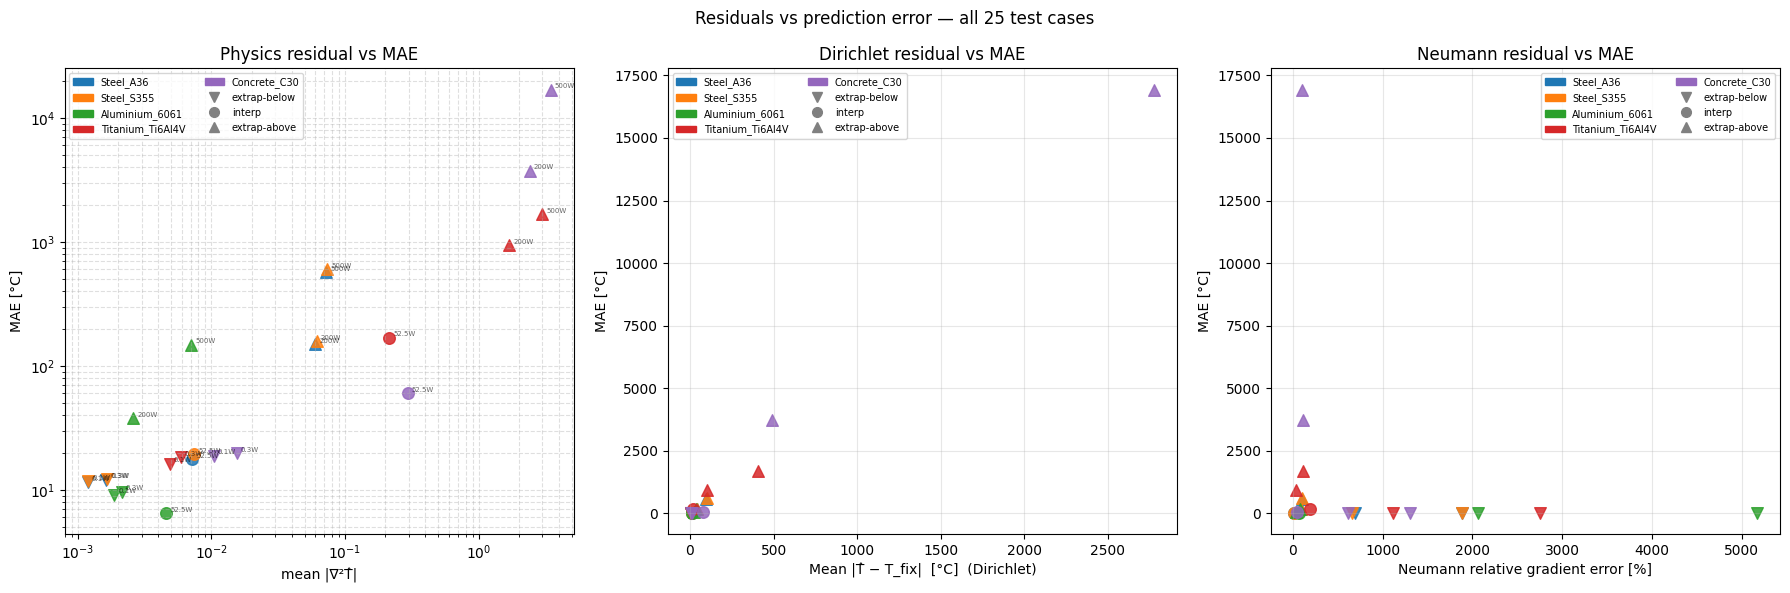

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Residuals vs prediction error — all 25 test cases', fontsize=12)

for r in summary_rows:
    col = MAT_COLORS.get(r['material'], 'gray')
    mk  = REGIME_MARKERS.get(r['regime'], 's')
    axes[0].scatter(r['mean_lap'],    r['mae'], color=col, marker=mk, s=70, alpha=0.85)
    axes[1].scatter(r['dir_mae'],     r['mae'], color=col, marker=mk, s=70, alpha=0.85)
    axes[2].scatter(r['neu_rel_pct'], r['mae'], color=col, marker=mk, s=70, alpha=0.85)
    axes[0].annotate(f"{r['q_W']:.3g}W", (r['mean_lap'], r['mae']),
                     fontsize=5, alpha=0.6, xytext=(3, 1), textcoords='offset points')

# Legends
mat_handles = [mpatches.Patch(color=MAT_COLORS[m], label=m) for m in MAT_ORDER]
reg_handles = [mlines.Line2D([], [], color='gray', marker=mk, linestyle='',
                              markersize=7, label=reg)
               for reg, mk in REGIME_MARKERS.items()]
leg_kw = dict(handles=mat_handles + reg_handles, fontsize=7, ncol=2)

axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('mean |∇²T̂|'); axes[0].set_ylabel('MAE [°C]')
axes[0].set_title('Physics residual vs MAE'); axes[0].legend(**leg_kw)
axes[0].grid(True, which='both', linestyle='--', alpha=0.4)

axes[1].set_xlabel('Mean |T̂ − T_fix|  [°C]  (Dirichlet)'); axes[1].set_ylabel('MAE [°C]')
axes[1].set_title('Dirichlet residual vs MAE'); axes[1].legend(**leg_kw)
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Neumann relative gradient error [%]'); axes[2].set_ylabel('MAE [°C]')
axes[2].set_title('Neumann residual vs MAE'); axes[2].legend(**leg_kw)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVES / 'pinn_residuals_vs_mae.png', dpi=130)
ipy_display(fig); plt.close(fig)

In [22]:
mae_arr = np.array([r['mae']         for r in summary_rows])
lap_arr = np.array([r['mean_lap']    for r in summary_rows])
dir_arr = np.array([r['dir_mae']     for r in summary_rows])
neu_arr = np.array([r['neu_rel_pct'] for r in summary_rows])

rho_lap, p_lap = spearmanr(lap_arr, mae_arr)
rho_dir, p_dir = spearmanr(dir_arr, mae_arr)
rho_neu, p_neu = spearmanr(neu_arr, mae_arr)

print('=== Spearman ρ vs MAE (all 25 cases) ===')
print(f'  |∇²T̂|   : ρ = {rho_lap:.3f}  (p={p_lap:.2e})')
print(f'  Dirichlet: ρ = {rho_dir:.3f}  (p={p_dir:.2e})')
print(f'  Neumann  : ρ = {rho_neu:.3f}  (p={p_neu:.2e})')
print()

print(f"{'Regime':14s}  {'N':>3}  {'MAE [°C]':>12}  {'mean|∇²T̂|':>12}  {'|Dir| [°C]':>11}  {'|Neu| [%]':>10}")
print('-' * 70)
for regime in ['extrap-below', 'interp', 'extrap-above']:
    sub = [r for r in summary_rows if r['regime'] == regime]
    if not sub:
        continue
    print(f"{regime:14s}  {len(sub):3d}  "          f"{np.mean([r['mae'] for r in sub]):12.2f}  "          f"{np.mean([r['mean_lap'] for r in sub]):12.3e}  "          f"{np.mean([r['dir_mae'] for r in sub]):11.4f}  "          f"{np.mean([r['neu_rel_pct'] for r in sub]):10.2f}")

=== Spearman ρ vs MAE (all 25 cases) ===
  |∇²T̂|   : ρ = 0.904  (p=5.97e-10)
  Dirichlet: ρ = 0.902  (p=7.12e-10)
  Neumann  : ρ = -0.447  (p=2.51e-02)

Regime            N      MAE [°C]    mean|∇²T̂|   |Dir| [°C]   |Neu| [%]
----------------------------------------------------------------------
extrap-below     10         13.99     4.627e-03       7.7442     1813.30
interp            5         54.54     1.058e-01      26.9263       66.15
extrap-above     10       2495.58     1.081e+00     411.6293       84.76


---
## Key questions

| Question | Where to look |
|----------|---------------|
| Does the model satisfy ∇²T=0 in the beam interior? | Section 3 — profile + correlation |
| Where does the Laplacian residual peak? | Section 3 — spatial overview, panel 4 |
| Is T̂(x=0) = T_fix? | Section 3 — Dirichlet detail |
| Does the slope ∂T̂/∂x match q/(k·A)? | Section 3 — Neumann detail |
| Which residual best predicts extrapolation failure? | Section 5 — Spearman ρ table |
| Does extrap-above have the highest Neumann error? | Section 5 — aggregate table |